**Exercise 9.2—Mini** Project Create a function that carries out Euler’s method
automatically for a constantly accelerating object. You need to provide the func-
tion with an acceleration vector, initial velocity vector, initial position vector, and
perhaps other parameters.


In [1]:
s0 = (0,0)
v0 = (1,0)
a = (0,0.2)

In [6]:
from vectors import add, scale
def eulers_method(s0,v0,a,total_time,step_count):

    positions = [s0]
    s = s0
    v = v0
    dt = total_time/step_count
    for _ in range(0,step_count):
        s = add(s,scale(dt,v))
        v = add(v,scale(dt,a))
        positions.append(s)
    return positions

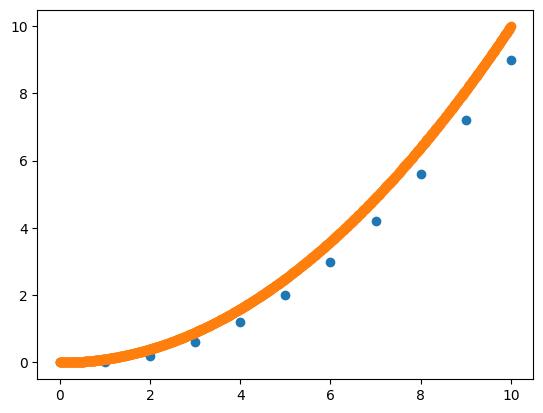

In [ ]:
import numpy as np
from matplotlib import pyplot as plt


V2 = tuple

def euler_constant_acceleration(s0: V2, v0: V2, a: V2, dt=0.5, total_time=1):
    s0arr, v0arr, aarr = (
        np.array(s0, dtype=float),
        np.array(v0, dtype=float),
        np.array(a, dtype=float),
    )
    for _ in range(round(total_time / dt)):
        yield s0arr.copy()
        s0arr += v0arr * dt
        v0arr += aarr * dt
    yield s0arr.copy()


test = euler_constant_acceleration((0, 0), (1, 0), (0, 0.2), 2)

step = 1
positions = [
    (i * step, p)
    for (i, p) in enumerate(
        euler_constant_acceleration(s0, v0, a, step, 10)
    )
]

_, ax = plt.subplots()

ax.scatter([p[0] for _, p in positions], [p[1] for _, p in positions])



step = 0.01
positions = [
    (i * step, p)
    for (i, p) in enumerate(
        euler_constant_acceleration((0, 0), (1, 0), (0, 0.2), step, 10)
    )
]
ax.scatter([p[0] for _, p in positions], [p[1] for _, p in positions])

plt.show()

**Exercise 9.3—Mini Project** In the calculation of section 9.4, we under approxi-
mated the y-coordinate of position because we updated the y component of the
velocity at the end of each time interval. Update the velocity at the beginning of
each time interval and show that you over approximate the y position over time.

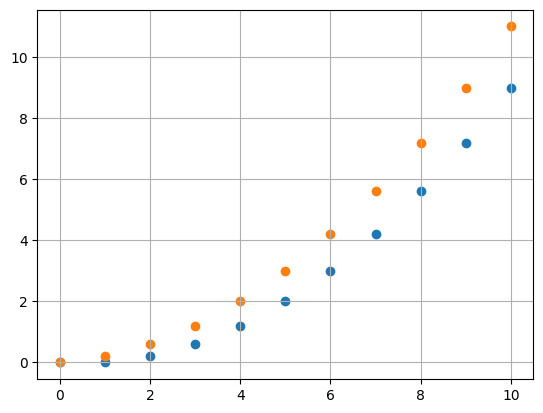

In [3]:

from email.mime import base

from matplotlib.ticker import MultipleLocator


def euler_constant_acceleration_over(s0: V2, v0: V2, a: V2, dt=0.5, total_time=1):
    s0arr, v0arr, aarr = (
        np.array(s0, dtype=float),
        np.array(v0, dtype=float),
        np.array(a, dtype=float),
    )
    for _ in range(round(total_time / dt)):
        yield s0arr.copy()
        v0arr += aarr * dt
        s0arr += v0arr * dt
    yield s0arr.copy()

positions = np.array(list(euler_constant_acceleration(s0, v0, a, 1, 10)))

_, ax = plt.subplots()


ax.scatter(positions[:, 0], positions[:, 1])

positions = np.array(list(euler_constant_acceleration_over(s0, v0, a, 1, 10)))
ax.scatter(positions[:, 0], positions[:, 1])

ax.grid()
# ax.yaxis.set_major_locator(MultipleLocator(1))

plt.show()

**Exercise 9.4—Mini Project** Any projectile like a thrown baseball, a bullet, or an
airborne snowboarder experiences the same acceleration vector: 9.81 m/s/s
toward the earth. If we think of the x-axis of the plane as flat ground with the
positive y-axis pointing upward, that amounts to an acceleration vector of (0,
9.81). If a baseball is thrown from shoulder height at x = 0, we could say its initial
position is (0, 1.5). Assume it’s thrown at an initial speed of 30 m/s at an angle
of 20° up from the positive x direction and simulate its trajectory with Euler’s
method. Approximately how far does the baseball go in the x direction before
hitting the ground?

In [17]:
from math import cos, pi, sin

def to_radians(grad: float):
    return pi * grad / 180

def from_polar(Vp: tuple[float, float]) -> V2:
    magnitude, angle = Vp
    x = magnitude * cos(angle)
    y = magnitude * sin(angle)
    return (x,y)



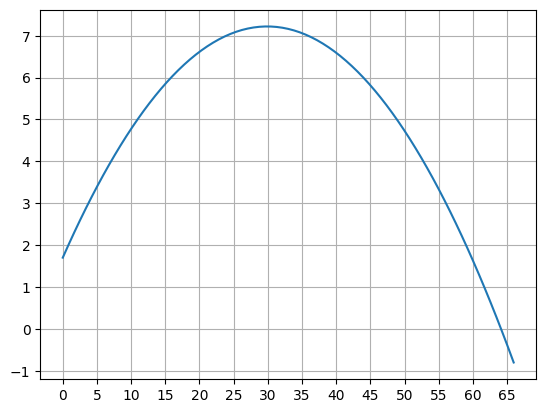

In [13]:
ga = (0, -9.81)

angle = 20 * pi / 180
v0 = (30 * cos(angle), 30 * sin(angle))

s0 = (0, 1.7)

_, ax = plt.subplots()
ax.grid()
points = np.array([p for p in euler_constant_acceleration(s0, v0, ga, 0.03, 3) if p[1] >= -1 ])
# points2 = np.array(eulers_method(s0, v0, ga, 3, 100))

ax.plot(points[:,0], points[:,1])
# ax.plot(points2[:,0], points2[:,1])
ax.xaxis.set_major_locator(MultipleLocator(5))
plt.show()

**Exercise 9.5—Mini Project** Rerun the Euler’s method simulation from the pre-
vious mini-project with the same initial speed of 30 but using an initial position
of (0, 0) and trying various angles for the initial velocity. What angle makes the
baseball go the farthest before hitting the ground?

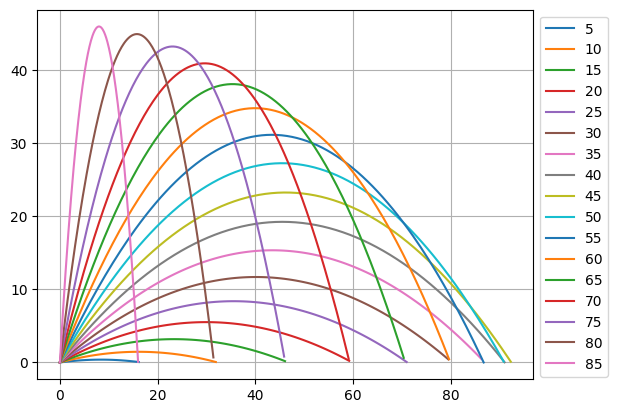

In [36]:
s0 = (0,0)
_, ax = plt.subplots()
ax.grid()
legends = []
for angle in range(5, 90, 5):
    v0 = from_polar((30, to_radians(angle)))
    points = np.array([p for p in euler_constant_acceleration(s0, v0, ga, 0.03, 10) if p[1] >= 0])
    ax.plot(points[:, 0], points[:, 1])
    legends.append(angle)
# Move legend outside the charting area
ax.legend(legends, bbox_to_anchor=(1, 1))

plt.show()

**Exercise 9.6—Mini Project** An object moving in 3D space has an initial velocity
of (1, 2, 0) and has a constant acceleration vector of (0, –1, 1). If it starts at the
origin, where is it after 10 seconds? Plot its trajectory in 3D using the drawing
functions from chapter 3.

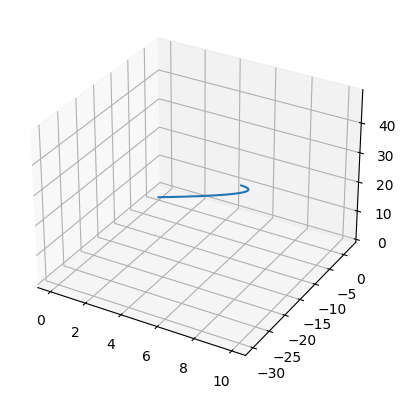

[ 10.   -29.95  49.95]


In [46]:
v03d = (1,2,0)
a3d = (0, -1, 1)
s03d = (0,0,0)

points = np.array([p for p in euler_constant_acceleration(s03d, v03d, a3d, 0.01, 10)])

ax = plt.figure().add_subplot(projection="3d")

ax.plot(points[:, 0], points[:, 1], points[:, 2])

plt.show()

print(points[-1])